# Goal:

This notebook is part of a series of tests that we want to perform to make sure out reconstruction algorithm is working as expected.

The `1Q_known_channel` showed us that we need to optimize the hyper-parameters of the optimization and allowed us to get MVE close to $10^{-4}$ and cost function values close to $10^{-9}$. This is better than what we had before but as good as what Raphael had. For this reason, we are now trying a fully noiseless optimization.

In [ ]:
import jax.numpy as jnp
import numpy as np

from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
from mGST.utility_functions_comparisons import kraus_tensor_to_mgst, get_compressed_rep_from_mgst_output, get_compressed_perturbed_kraus_from_superop, get_compressed_perturbed_rep_from_mgst, all_operators_from_configuration
from mGST.simulate import run_optimization_workflow, average_and_std_mve, mve_avg_and_std_from_list_of_superops
from mGST.visualization import plot_cost_function

# need to tune options for 1Q optimization
from mGST.typing import OperatorSchedule, TrustRegionOptions

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Noiseless tensors

In [14]:
shots = 1000
num_sequences = 100
backend = "iqmfakeapollo" # just to create the benchmark and then get the gate set

In [28]:
Minimal_1Q_GST = GSTConfiguration(
    qubit_layouts=[[0]],
    gate_set="1QXYI",
    num_circuits=num_sequences,
    shots=shots,
    rank=4,
    verbose_level=2,
    convergence_criteria =  [3, 1e-20],
    max_iterations = [0,40],
    opt_method = "SFN",
    from_init = True,
    )

target_operators = all_operators_from_configuration(Minimal_1Q_GST, backend)
print(target_operators.keys())

for key in ["kraus", "povm", "state"]:
    print(f"{key}: {target_operators[key].shape}")

dict_keys(['kraus', 'povm', 'state', 'gate_labels'])
kraus: (3, 1, 2, 2)
povm: (2, 4)
state: (4,)


In [29]:
# now get the superoperator for Kraus
povm_vect_target = target_operators["povm"]
state_vect_target = target_operators["state"]
kraus_tensor_unitary_target = target_operators["kraus"]
kraus_superop_target = kraus_tensor_to_mgst(kraus_tensor_unitary_target)
kraus_superop_target.shape

(3, 4, 4)

In [34]:
num_qubits = 1
dim = 2**num_qubits
kraus_rank = dim**2
povm_rank = dim
state_rank = dim
num_gates = 3

In [37]:
# first the target
kraus_tensor_target, povm_psd_target, state_psd_target = get_compressed_rep_from_mgst_output(kraus_superop_target, povm_vect_target, state_vect_target, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

target_psd_operators = {
    "kraus": kraus_tensor_target,
    "povm": povm_psd_target,
    "state": state_psd_target
}
print("Target operators shapes:")
[op.shape for op in target_psd_operators.values()]

Target operators shapes:


[(3, 4, 2, 2), (2, 2, 2), (2, 2)]

# Initial tensors

In [ ]:
kraus_tensor_init_dict = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=kraus_rank, seed=42)
kraus_tensor_init = kraus_tensor_init_dict["kraus_tensor"]

povm_psd_init, state_psd_init = get_compressed_perturbed_rep_from_mgst(povm_vect_target, state_vect_target, rank_povm=povm_rank, rank_state=state_rank)

init_operators = {
    "kraus": kraus_tensor_init,
    "povm": povm_psd_init,
    "state": state_psd_init,
}

true_superops={
    "kraus": kraus_superop_target,
    "povm": povm_vect_target,
    "state": state_vect_target
}

print(f"shapes: {[v.shape for v in init_operators.values()]}")
print(f"shapes: {[v.shape for v in true_superops.values()]}")

shapes: [(3, 4, 2, 2), (2, 2, 2), (2, 2)]
shapes: [(3, 4, 4), (2, 4), (4,)]


# Optimization

In [39]:
num_iterations_outer = 20
num_iterations_tr = 5
num_iterations_cg = 10 
tol_grad = 1e-8 # it was 1e-4 before. 1e-8 is suggested in the book.

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad))

relative_precision = 1e-13 #
global_grad_norm_tol = 1e-10 #

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}

optimization_options = {
    "schedule": optimization_schedule_all_tr,
    "num_iterations_outer": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_grad_norm_tol
}
optimization_options

{'schedule': {'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
  'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
  'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))])},
 'num_iterations_outer': 20,
 'relative_precision': 1e-13,
 'global_gradient_norm_tol': 1e-10}

In [40]:
optimization_results_100_seq_exact = run_optimization_workflow(
    num_sequences=100,
    num_shots=shots,
    init_operators=init_operators,
    operators_psd_true=target_psd_operators,
    target_superops=true_superops,
    use_exact_probabilities=True,
    optimization_options=optimization_options,
    warmup_run=True
)

Using exact probabilities 🔪
🏎️ Warming up the cost function ...
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 4 the new count changed to: 3
at iteration 10 the new count changed to: 4
at iteration 16 the new count changed to: 5
at iteration 22 the new count changed to: 6
at iteration 29 the new count changed to: 7
at iteration 36 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15
Initial cost value: 0.0009311431507664573
🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-19]: TrustRegionOptions
povm: Schedule:
  [0-19]: TrustRegionOptions
state: Schedule:
  [0-19]: TrustRegionOptions 
* Convergence Criteria: 
+ R

In [47]:
shots_list = np.logspace(2,6,5)
shots_list

array([1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06])

In [48]:
optimization_results_list = []
for num_shots in shots_list:
    print(f"Running optimization for num_shots={num_shots}")
    print("--------------------------------")
    optimization_result_i = run_optimization_workflow(
        num_sequences=100,
        num_shots=num_shots,
        init_operators=init_operators,
        operators_psd_true=target_psd_operators,
        target_superops=true_superops,
        use_exact_probabilities=False,
        optimization_options=optimization_options,
        warmup_run=False,
    )
    print(f"Finished optimization for num_shots={num_shots}")
    print("--------------------------------")
    optimization_results_list.append(optimization_result_i)

Running optimization for num_shots=100.0
--------------------------------
🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-19]: TrustRegionOptions
povm: Schedule:
  [0-19]: TrustRegionOptions
state: Schedule:
  [0-19]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-13 
+ Gradient(s) Norm(s) 📐
at iteration 0 the new count changed to: 31
at iteration 1 the new count changed to: 32
at iteration 4 the new count changed to: 33
at iteration 10 the new count changed to: 34
at iteration 16 the new count changed to: 35
at iteration 22 the new count changed to: 36
at iteration 29 the new count changed to: 37
at iteration 36 the new count changed to: 38
at iteration 43 the new count changed to: 39
at iteration 50 the new count changed to: 40
at iteration 58 the new count changed to: 41
at iteration 66 the new count changed to: 42
at iteration 74 the new count changed to: 43
at iteration 82 the new count changed to: 44
at iteration 9

# Analysis

## Shots dependency 

In [52]:
gst_superops_list = [res["superops_gauged"] for res in optimization_results_list]
num_shots_samples = 10000
num_random_runs = 10

In [56]:
seq_lengths = [8, 16, 32, 64]

mve_avg_std_vs_length = {}

for length in seq_lengths:
    print(f"⭐️ Computing MVE for sequence length: {length}")
    mve_avg_std_vs_length[length] = mve_avg_and_std_from_list_of_superops(num_runs=num_random_runs, true_superops=true_superops, gst_superops=gst_superops_list, length=length, samples=num_shots_samples)

⭐️ Computing MVE for sequence length: 8
Processing superop no.: 0
Processing superop no.: 1
Processing superop no.: 2
Processing superop no.: 3
Processing superop no.: 4
⭐️ Computing MVE for sequence length: 16
Processing superop no.: 0
Processing superop no.: 1
Processing superop no.: 2
Processing superop no.: 3
Processing superop no.: 4
⭐️ Computing MVE for sequence length: 32
Processing superop no.: 0
Processing superop no.: 1
Processing superop no.: 2
Processing superop no.: 3
Processing superop no.: 4
⭐️ Computing MVE for sequence length: 64
Processing superop no.: 0
Processing superop no.: 1
Processing superop no.: 2
Processing superop no.: 3
Processing superop no.: 4


In [75]:
def compute_linear_fit_of_exponential_data(x:jnp.ndarray, y:jnp.ndarray, base:float=10.0):
    """Compute the linear fit of exponential data by linearizing the data and performing a linear regression."""
    # linearize
    log_y = jnp.log(y) / jnp.log(base)
    log_x = jnp.log(x) / jnp.log(base)
    
    # linear fit
    coeffs = jnp.polyfit(log_x, log_y, deg=1)
    slope, intercept = coeffs
    return slope, intercept
    
def generate_fitted_values(x:jnp.ndarray, y:jnp.ndarray, base:float=10.0):
    """Generate fitted values for exponential data by linearizing the data, performing a linear regression, and then exponentiating the fitted values."""
    slope, intercept = compute_linear_fit_of_exponential_data(x, y, base)
    log_x = jnp.log(x) / jnp.log(base)
    log_y_fit = slope * log_x + intercept
    y_fit = base ** log_y_fit
    return y_fit, slope, intercept

import matplotlib.pyplot as plt

def plot_mve_multiple_seq_lengths(mve_dict:dict[int, list[tuple]], shots_list:jnp.ndarray, title:str|None=None):
    """Plot the MVE against number of shots for different number of sequences."""
    parameters_dict = {}

    fig, ax = plt.subplots(figsize=(10, 7), dpi=200)
    # Color palette for different sequence lengths
    colours = plt.cm.viridis(np.linspace(0, 1, len(seq_lengths)))
    
    for seq_length, colour in zip(mve_dict.keys(), colours):
        
        mve_vs_shots = mve_dict[seq_length]
        if isinstance(mve_vs_shots[0], tuple):
            # we are taking only the avg out of a tuple (avg, std)
            mve_vs_shots = [result[0] for result in mve_vs_shots]
        mve_vs_shots = jnp.array(mve_vs_shots)
        
        y_fit, slope, intercept = generate_fitted_values(x=shots_list, y=mve_vs_shots, base=10)
        
        parameters_dict[seq_length] = (slope, intercept)
        
        
        # Plot data and fit for this sequence length
        ax.loglog(shots_list, mve_vs_shots, 'o', linewidth=2, markersize=8,
                 color=colour, label=f'seq_len={seq_length} (data)')
        ax.loglog(shots_list, y_fit, '--', linewidth=2, color=colour,
                 label=f'seq_len={seq_length} (fit, slope={slope:.3f})')
        
    ax.set_xlabel('Number of Shots', fontsize=14)
    ax.set_ylabel('Mean Variation Error', fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=10, loc='best')

    plt.tight_layout()
    plt.show()
    
    return fig, parameters_dict

In [105]:
def compute_weighted_linear_fit_of_exponential_data(
    x: jnp.ndarray,
    y_avg_std: list[tuple[float, float]],
    base: float = 10.0,
    eps: float = 1e-30,
):
    """
    Weighted fit of log_b(y) = slope * log_b(x) + intercept,
    where weights come from y_std.

    Uses propagated uncertainty:
        sigma_logy = y_std / (y * ln(base))
        w = 1 / sigma_logy^2
    """
    x = jnp.asarray(x, dtype=jnp.float64)
    y = jnp.asarray([val for val, _ in y_avg_std], dtype=jnp.float64)
    y_std = jnp.asarray([std for _, std in y_avg_std], dtype=jnp.float64)

    # Keep only physically valid points for log transform and weighting
    valid = (x > 0.0) & (y > 0.0) & (y_std > 0.0)
    x = x[valid]
    y = y[valid]
    y_std = y_std[valid]

    if x.size < 2:
        raise ValueError("Need at least 2 valid points with x>0, y>0, y_std>0.")

    ln_base = jnp.log(base)
    log_x = jnp.log(x) / ln_base
    log_y = jnp.log(y) / ln_base

    sigma_log_y = y_std / (y * ln_base)
    sigma_log_y = jnp.maximum(sigma_log_y, eps)
    w = 1.0 / (sigma_log_y ** 2)

    # Weighted least squares closed form
    S = jnp.sum(w)
    Sx = jnp.sum(w * log_x)
    Sy = jnp.sum(w * log_y)
    Sxx = jnp.sum(w * log_x * log_x)
    Sxy = jnp.sum(w * log_x * log_y)

    Delta = S * Sxx - Sx * Sx
    if jnp.abs(Delta) < eps:
        raise ValueError("Degenerate fit: check x values and uncertainties.")

    slope = (S * Sxy - Sx * Sy) / Delta
    intercept = (Sxx * Sy - Sx * Sxy) / Delta

    # Optional 1-sigma parameter uncertainties and covariance
    slope_std = jnp.sqrt(S / Delta)
    intercept_std = jnp.sqrt(Sxx / Delta)
    cov_slope_intercept = -Sx / Delta

    return slope, intercept, slope_std, intercept_std, cov_slope_intercept

def generate_weighted_fitted_values(
    x: jnp.ndarray,
    y_avg_std: list[tuple[float, float]],
    base: float = 10.0,
):
    slope, intercept, slope_std, intercept_std, cov = (
        compute_weighted_linear_fit_of_exponential_data(x, y_avg_std, base=base)
    )
    log_x = jnp.log(x) / jnp.log(base)
    log_y_fit = slope * log_x + intercept
    y_fit = base ** log_y_fit
    return y_fit, slope, intercept, slope_std, intercept_std, cov

def plot_mve_multiple_seq_lengths_with_error_bars(mve_dict: dict[int, list[tuple]], shots_list: jnp.ndarray, title: str | None = None):
    """Plot the MVE against number of shots for different sequence lengths, with error bars and weighted fit."""
    parameters_dict = {}
    handles, labels = [], []

    fig, ax = plt.subplots(figsize=(10, 7), dpi=200)
    colours = plt.cm.viridis(np.linspace(0, 1, len(mve_dict.keys())))

    for seq_length, colour in zip(mve_dict.keys(), colours):
        mve_vs_shots = mve_dict[seq_length] # list of tuples (avg, std)

        y_fit, slope, intercept, slope_std, *_ = generate_weighted_fitted_values(
            x=shots_list, y_avg_std=mve_vs_shots, base=10
        )

        parameters_dict[seq_length] = (slope, intercept, slope_std)

        mve_avg = jnp.array([val for val, _ in mve_vs_shots])
        mve_std = jnp.array([std for _, std in mve_vs_shots])

        error_bar = ax.errorbar(
            shots_list, mve_avg, yerr=mve_std,
            fmt='o', markersize=8, capsize=4, linewidth=1.5,
            color=colour
        )
        line, = ax.loglog(shots_list, y_fit, '--', linewidth=2, color=colour)

        handles += [error_bar, line]
        labels += [
            f'seq_len={seq_length} (data ± std)',
            f'seq_len={seq_length} (weighted fit, slope={slope:.3f}±{slope_std:.3f})',
        ]

    
    ax.set_xlabel('Number of Shots', fontsize=14)
    ax.set_ylabel('Mean Variation Error', fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(handles, labels, fontsize=10, loc='best')
    ax.set_xlim(shots_list[0] * 0.5, shots_list[-1] * 2)  # <-- add this

    plt.tight_layout()
    plt.show()

    return fig, parameters_dict

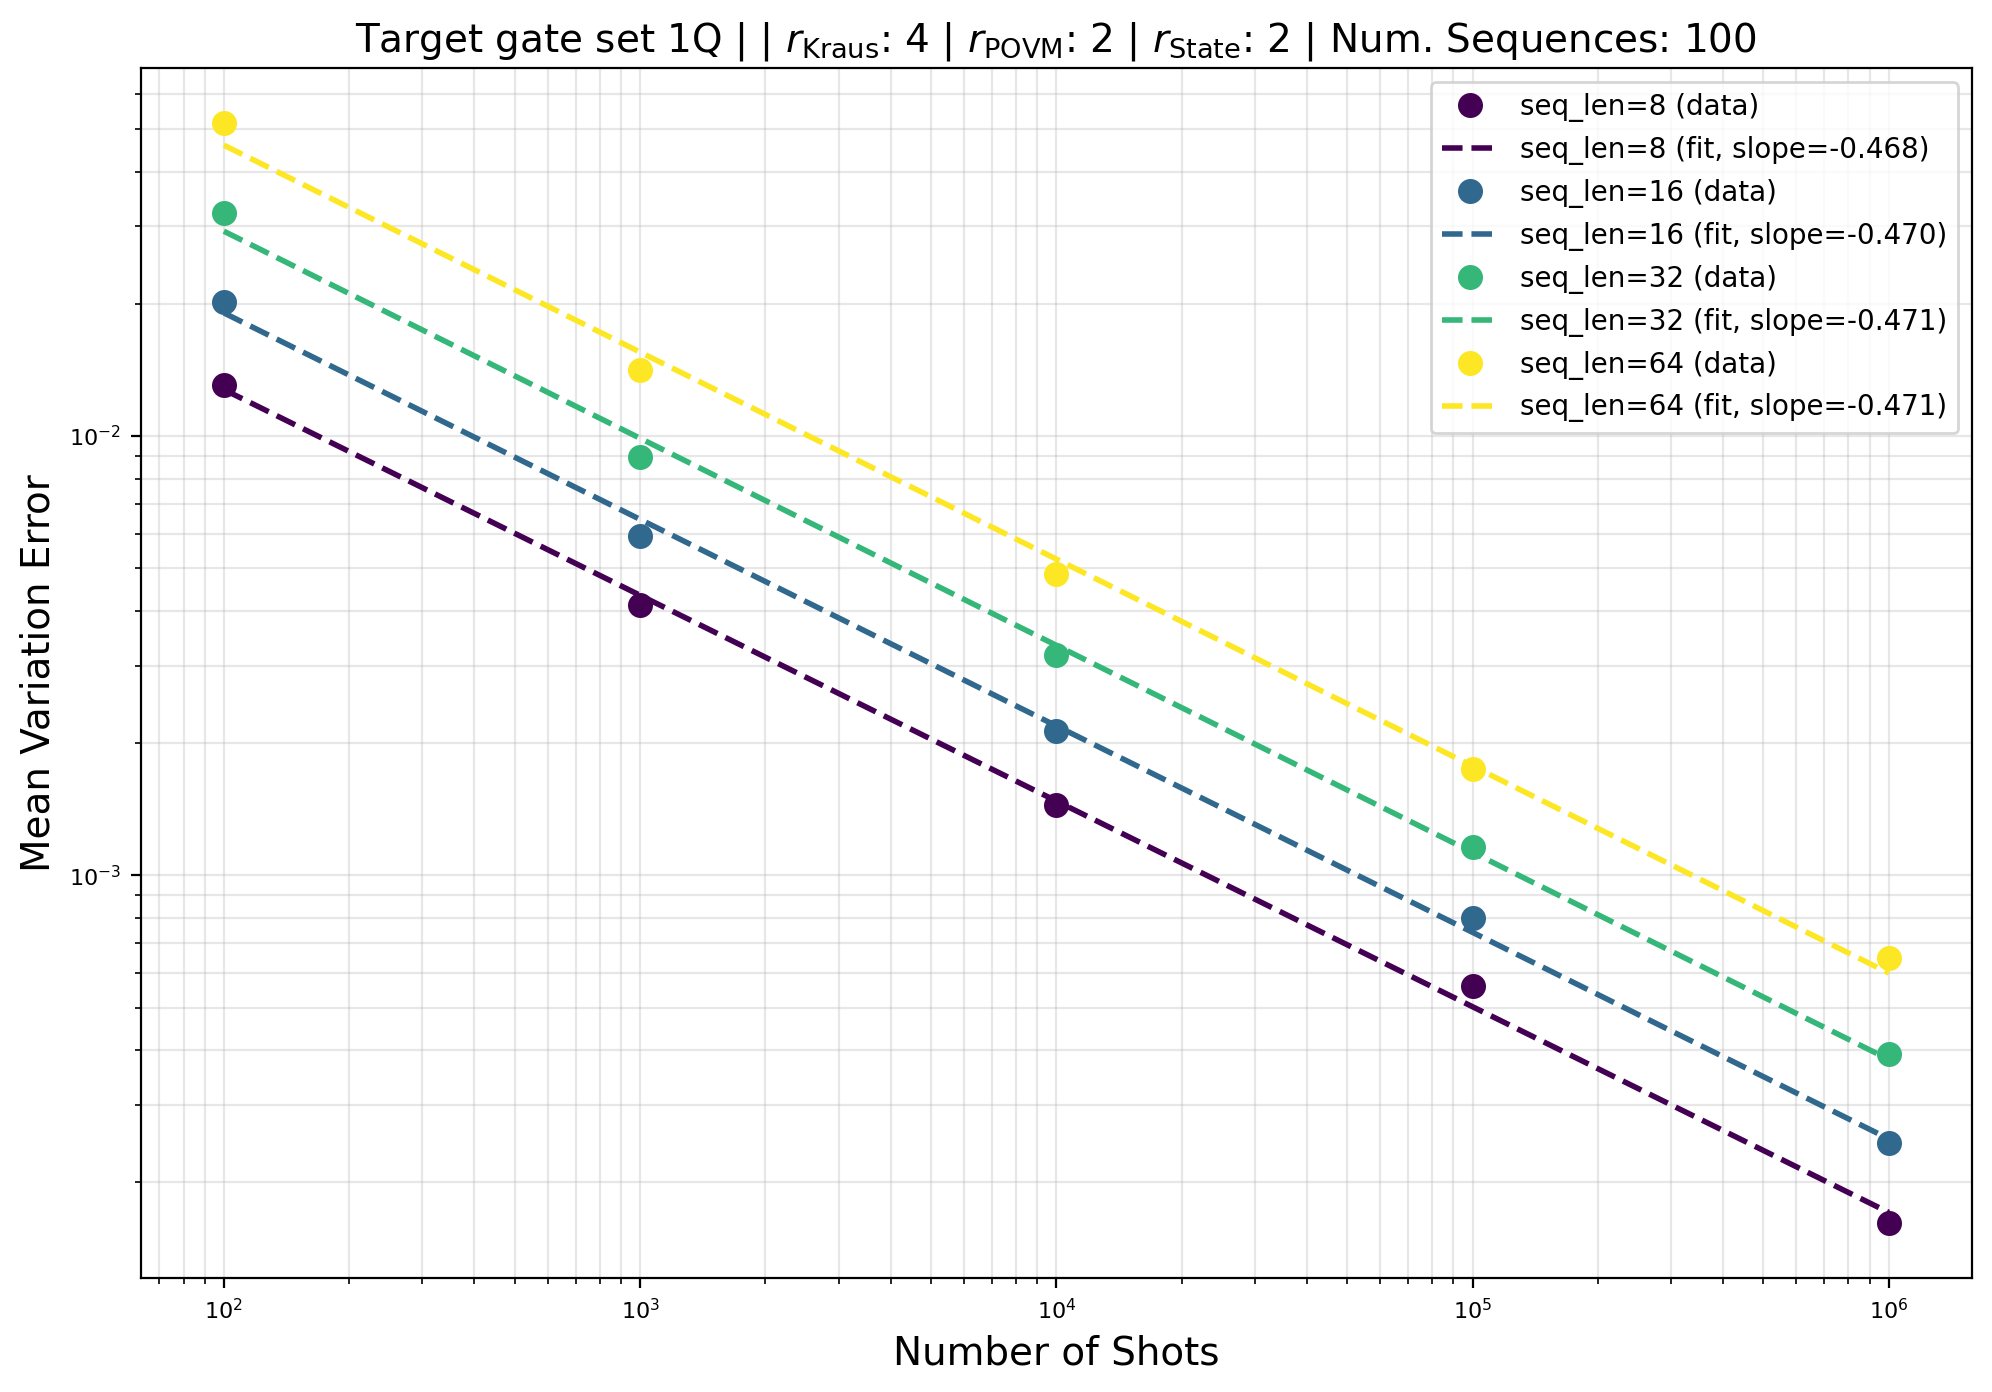

In [76]:
title = rf'Target gate set {num_qubits}Q | | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Num. Sequences: 100'
fig, parameters_dict = plot_mve_multiple_seq_lengths(mve_dict=mve_avg_std_vs_length, shots_list=shots_list, title=title)

In [108]:
mve_avg_std_vs_length[8]

[(Array(0.01305467, dtype=float64), Array(0.00010951, dtype=float64)),
 (Array(0.00412029, dtype=float64), Array(3.10011011e-05, dtype=float64)),
 (Array(0.00144514, dtype=float64), Array(1.27969963e-05, dtype=float64)),
 (Array(0.00055913, dtype=float64), Array(7.75360698e-06, dtype=float64)),
 (Array(0.00016144, dtype=float64), Array(1.71923347e-06, dtype=float64))]

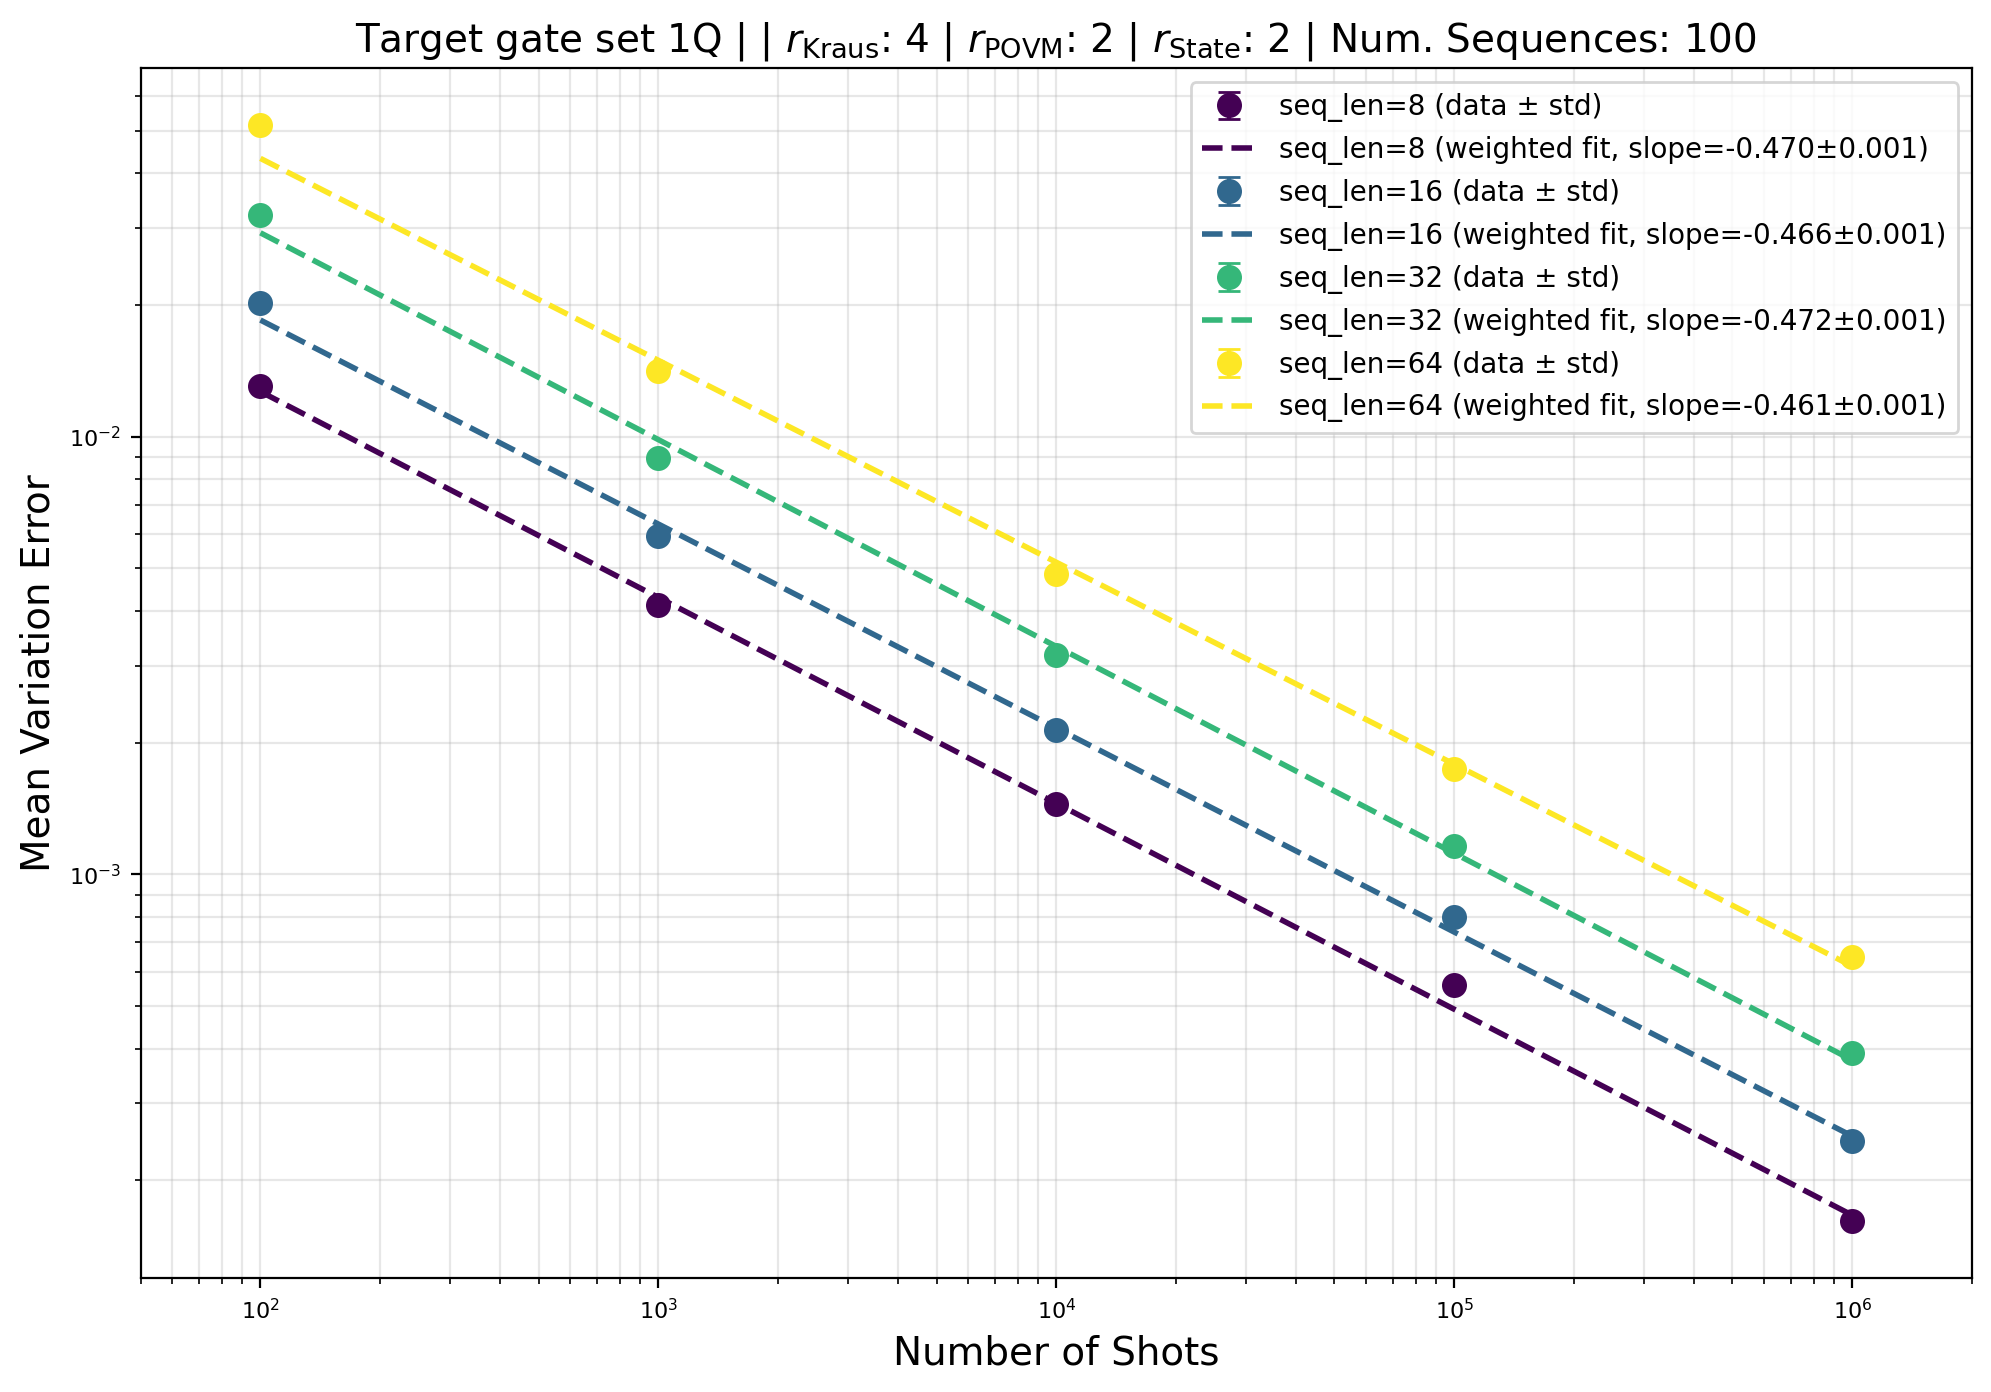

In [106]:
fig, parameters_dict = plot_mve_multiple_seq_lengths_with_error_bars(mve_dict=mve_avg_std_vs_length, shots_list=shots_list, title=title)

## Cost function visualization (just to check)

In [79]:
optimization_results_list[0].keys()

dict_keys(['optimized_operators', 'superops_gauged', 'target_model_pygsti', 'cost_fn_history', 'probability_matrices', 'indices_dict', 'times'])

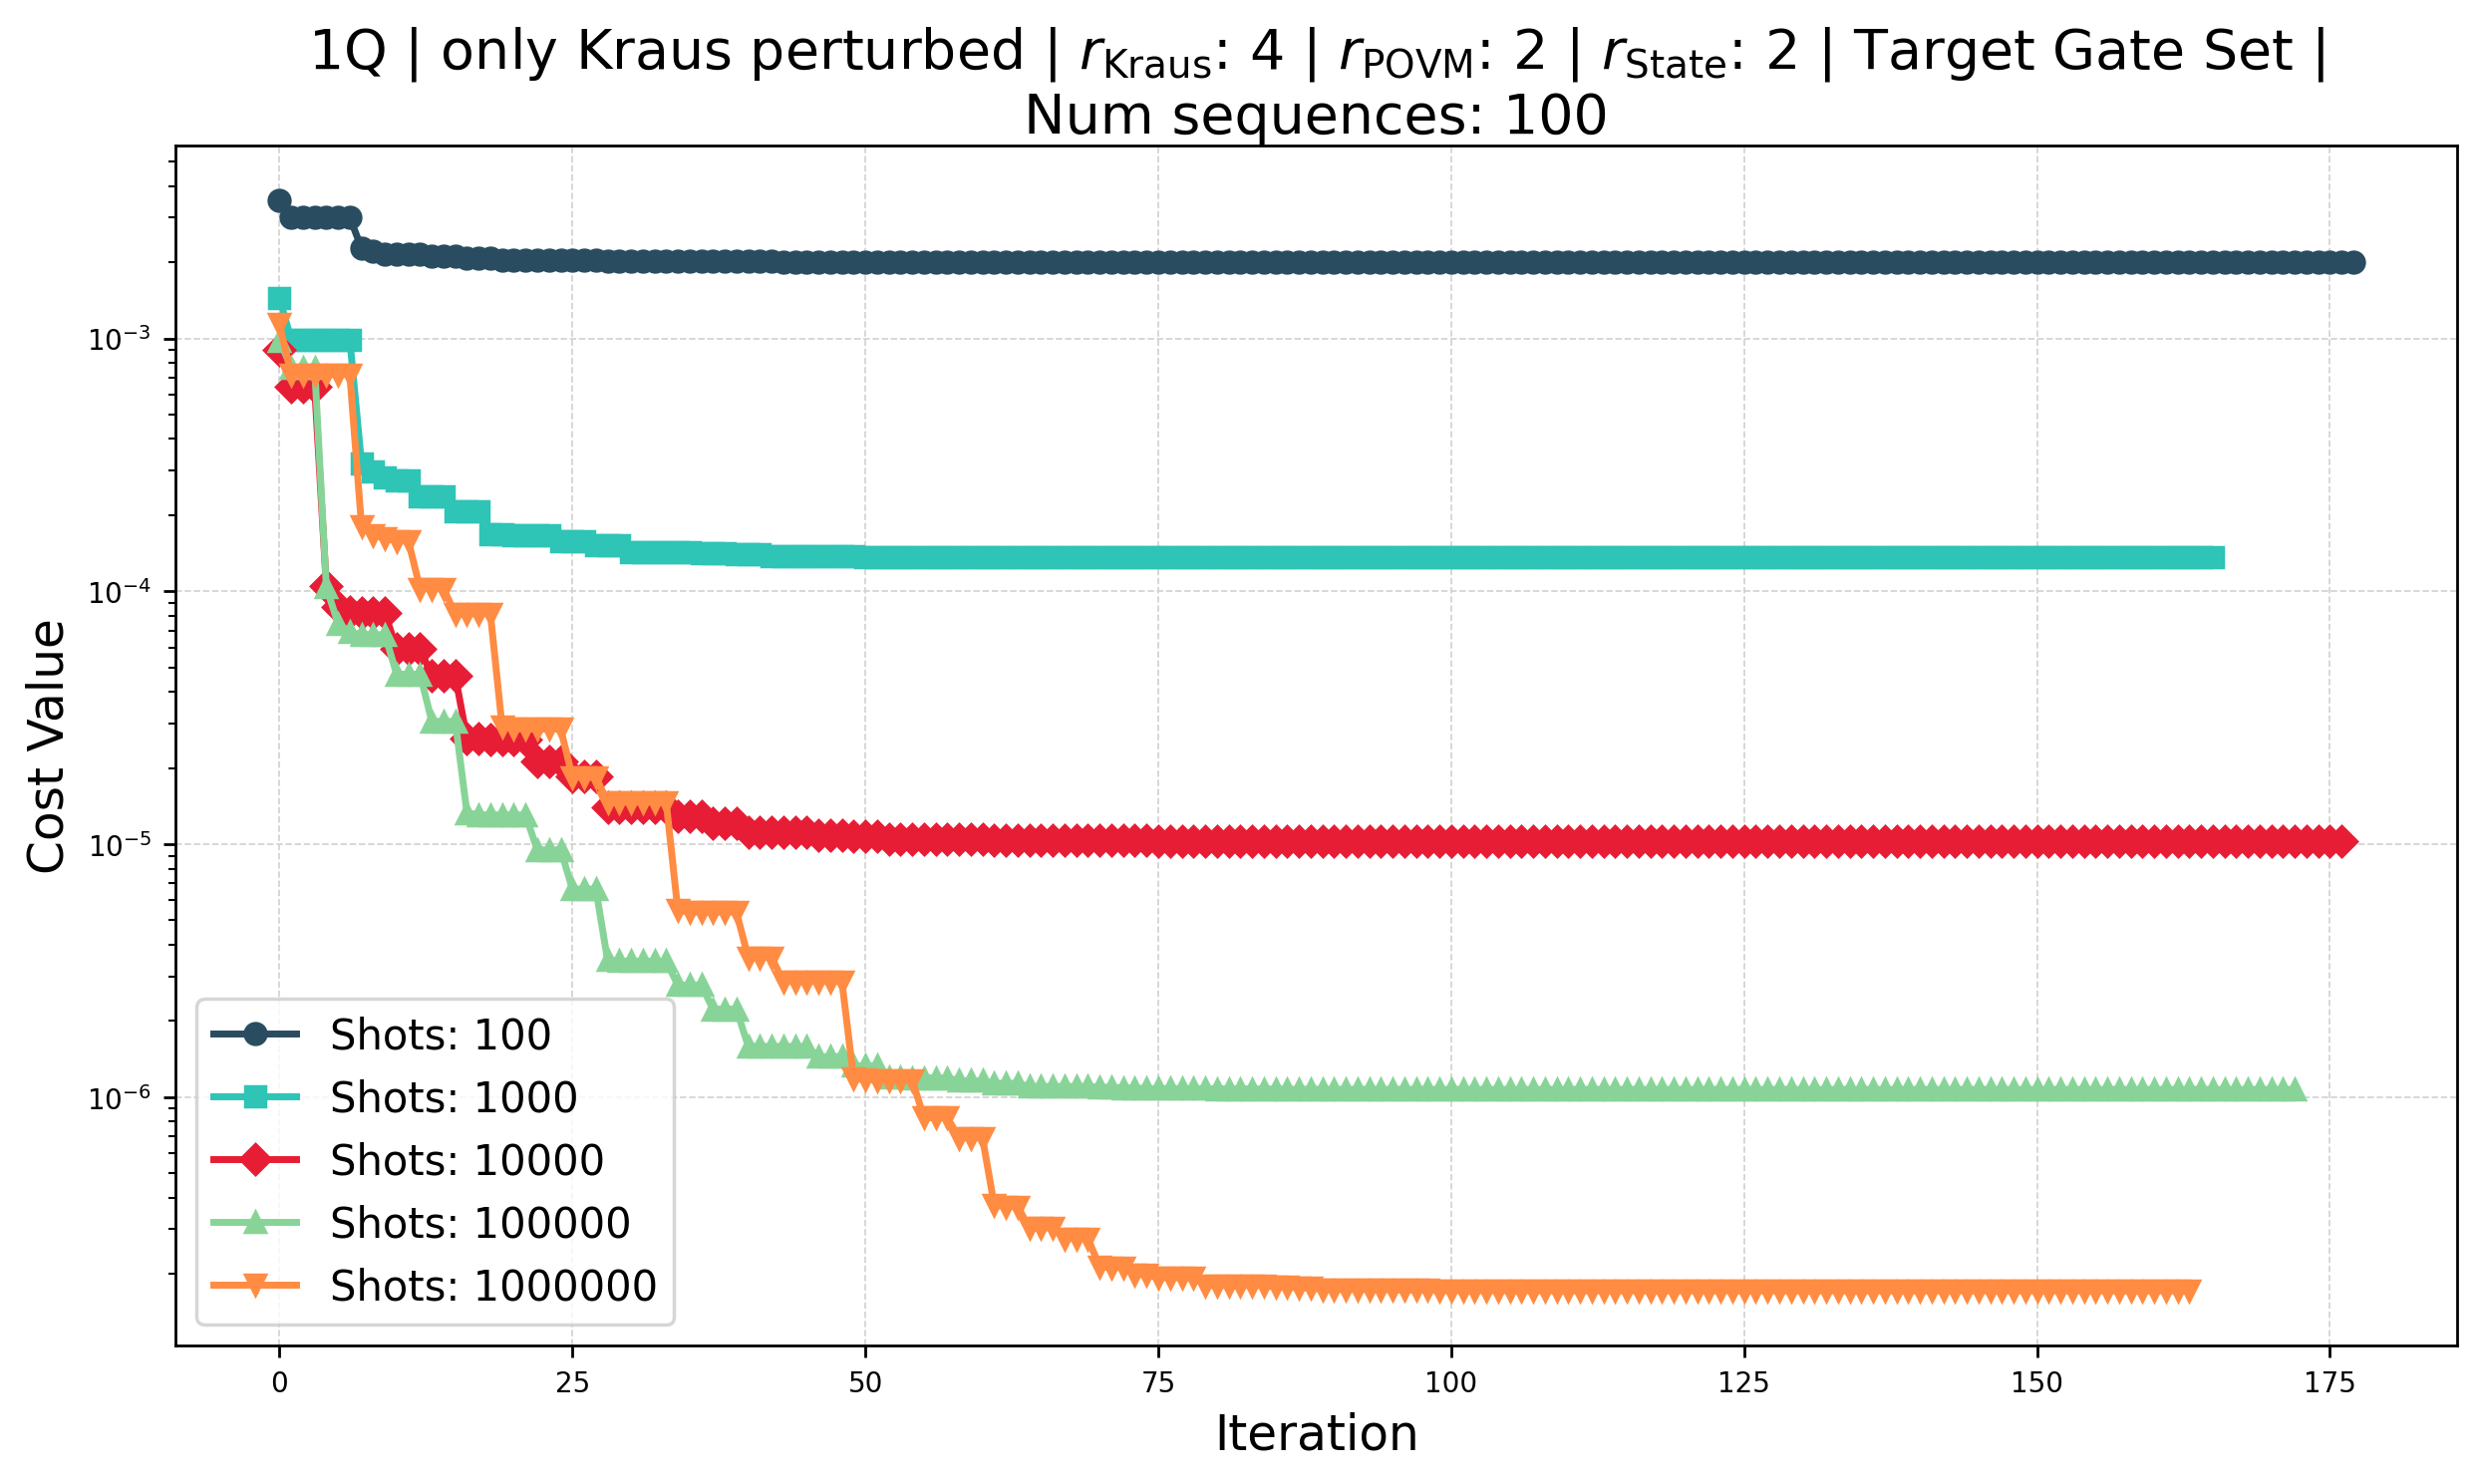

In [84]:
cost_fn_vs_shots = [res["cost_fn_history"] for res in optimization_results_list]
title_cost_fn_vs_shots = rf"{num_qubits}Q | only Kraus perturbed | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Target Gate Set |" + "\n" + f"Num sequences: {num_sequences}"

labels_cst_fn_vs_shots = [f"Shots: {int(num_shots)}" for num_shots in shots_list]

plot_cost_function(cost_fn_vs_shots, title=title_cost_fn_vs_shots, labels=labels_cst_fn_vs_shots, comparison_yline=None)

## Exact

In [41]:
superops_gauged_100_seq_exact = optimization_results_100_seq_exact["superops_gauged"]
kraus_superop_gauged_100_seq_exact = superops_gauged_100_seq_exact["kraus"]
indices_dict_100_seq_exact = optimization_results_100_seq_exact["indices_dict"]
probability_matrices_100_seq_exact = optimization_results_100_seq_exact["probability_matrices"]
cost_fn_100_seq_exact = optimization_results_100_seq_exact["cost_fn_history"]
time_100_seq_exact = optimization_results_100_seq_exact["times"]["optimization_time"]

# diamond_distances_optimized_100_seq_exact = diamond_norm_distances(superop1=kraus_superop_gauged_100_seq_exact, superop2=kraus_superop_noisy_np)

mve_100_seq_exact = average_and_std_mve(true_superops=true_superops, gst_superops=superops_gauged_100_seq_exact, length=14, samples=1000, num_runs=10)

mve_100_seq_exact, time_100_seq_exact

((Array(8.16331451e-07, dtype=float64), Array(2.171339e-08, dtype=float64)),
 272.7842900753021)

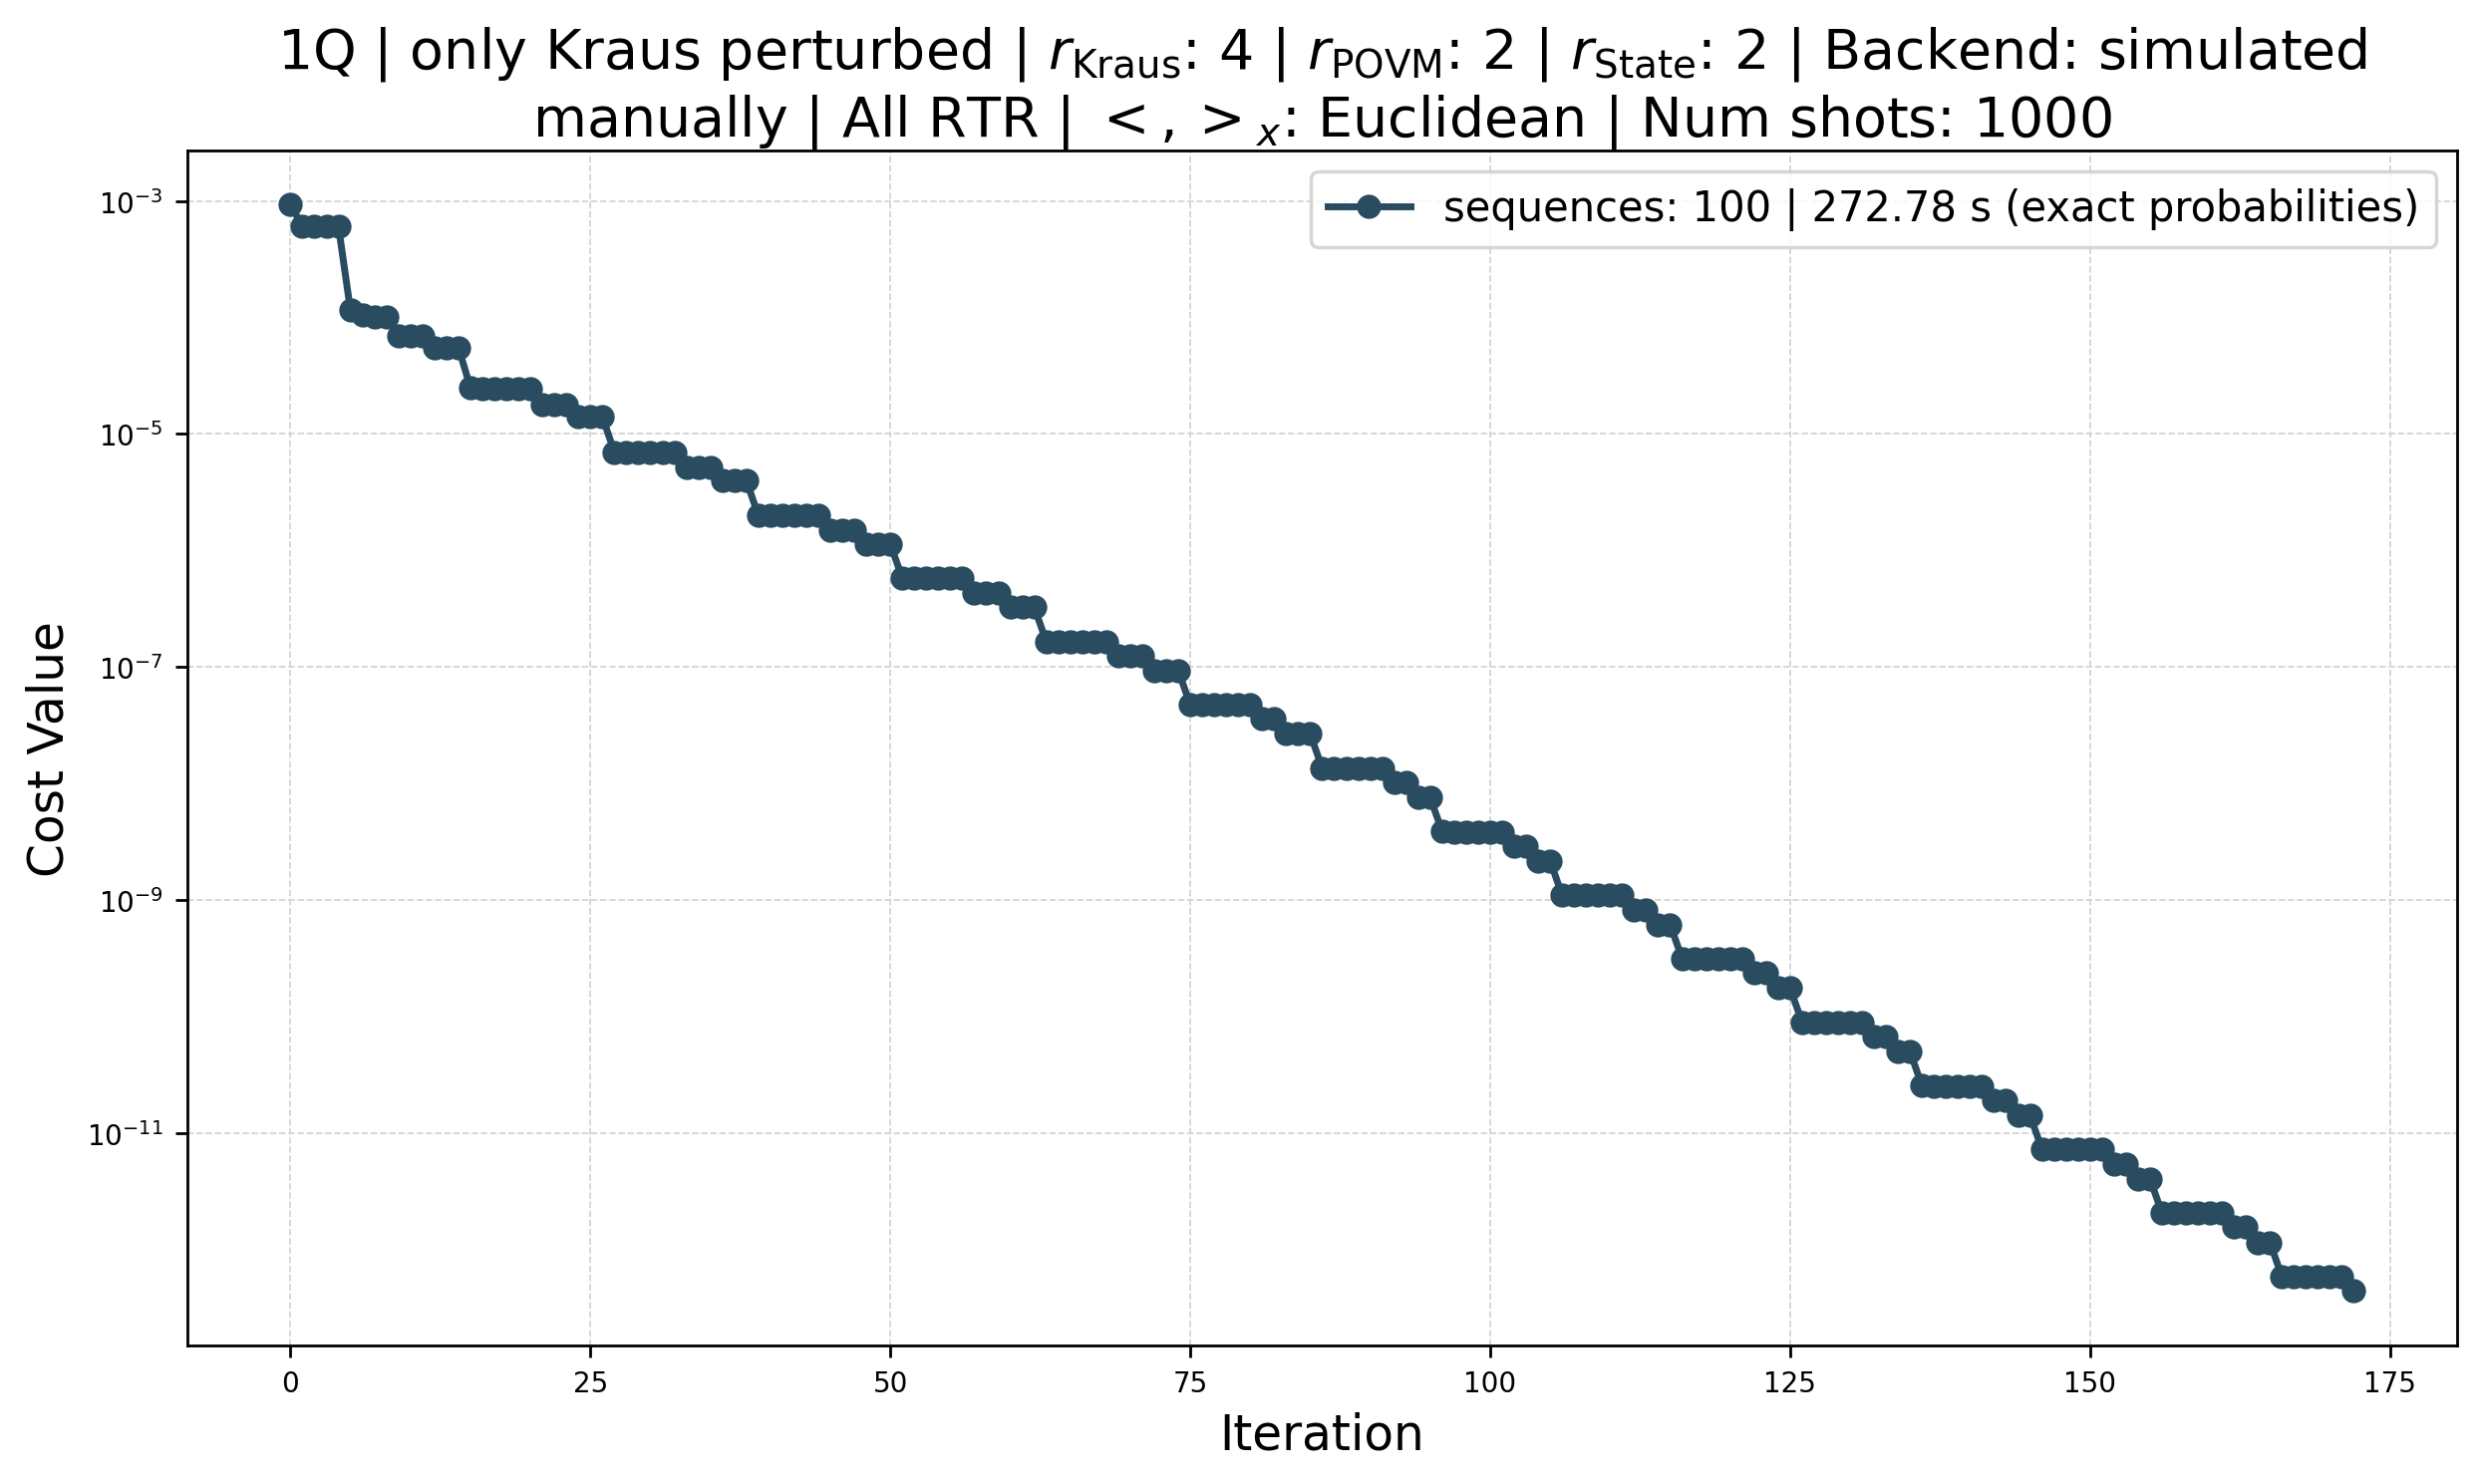

In [46]:
cost_fn_lists = []
cost_fn_lists.append(cost_fn_100_seq_exact)

labels_cost_fns = []
labels_cost_fns.append(f"sequences: 100 | {time_100_seq_exact:.2f} s (exact probabilities)")

title_cost_fn = rf"{num_qubits}Q | only Kraus perturbed | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Backend: simulated manually | All RTR | $<,>_x$: Euclidean | Num shots: {shots}"

plot_cost_function(cost_fn_lists, title=title_cost_fn, labels=labels_cost_fns, comparison_yline=None, use_semilogy=True)